In [19]:
%load_ext autoreload
%autoreload 2

In [20]:
import multiprocessing

# Get the number of CPUs
num_cpus = multiprocessing.cpu_count()
print(f"Number of CPUs available: {num_cpus}")


Number of CPUs available: 64


In [21]:
import psutil   

# Get memory information
mem = psutil.virtual_memory()
total_memory = mem.total / (1024 ** 3)  # Convert bytes to GB
available_memory = mem.available / (1024 ** 3)  # Convert bytes to GB

print(f"Total Memory: {total_memory:.2f} GB")
print(f"Available Memory: {available_memory:.2f} GB")


Total Memory: 503.61 GB
Available Memory: 416.57 GB


In [22]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))



In [23]:
path_to_visium_folder ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-10767_rep/outs"

In [24]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
import seaborn as sns

# Reload the model module if you're actively developing

path_to_biopsy ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS19-12947/outs"

path_to_surgical ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-10767_rep/outs"


path_list = [path_to_biopsy, path_to_surgical]

In [25]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2141 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 763 Filtered spots: 794 to 763
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "10.201.0.113"


Refining Cell Proportions: 100%|██████████| 763/763 [02:39<00:00,  4.78it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1', 'AACTGCCTCGATAGGT-1', 'AACTTCGCTTAGTCAG-1', 'AACTTGGTTAATACTA-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1', 'AACTGCCTCGATAGGT-1', 'AACTTCGCTTAGTCAG-1', 'AACTTGGTTAATACTA-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


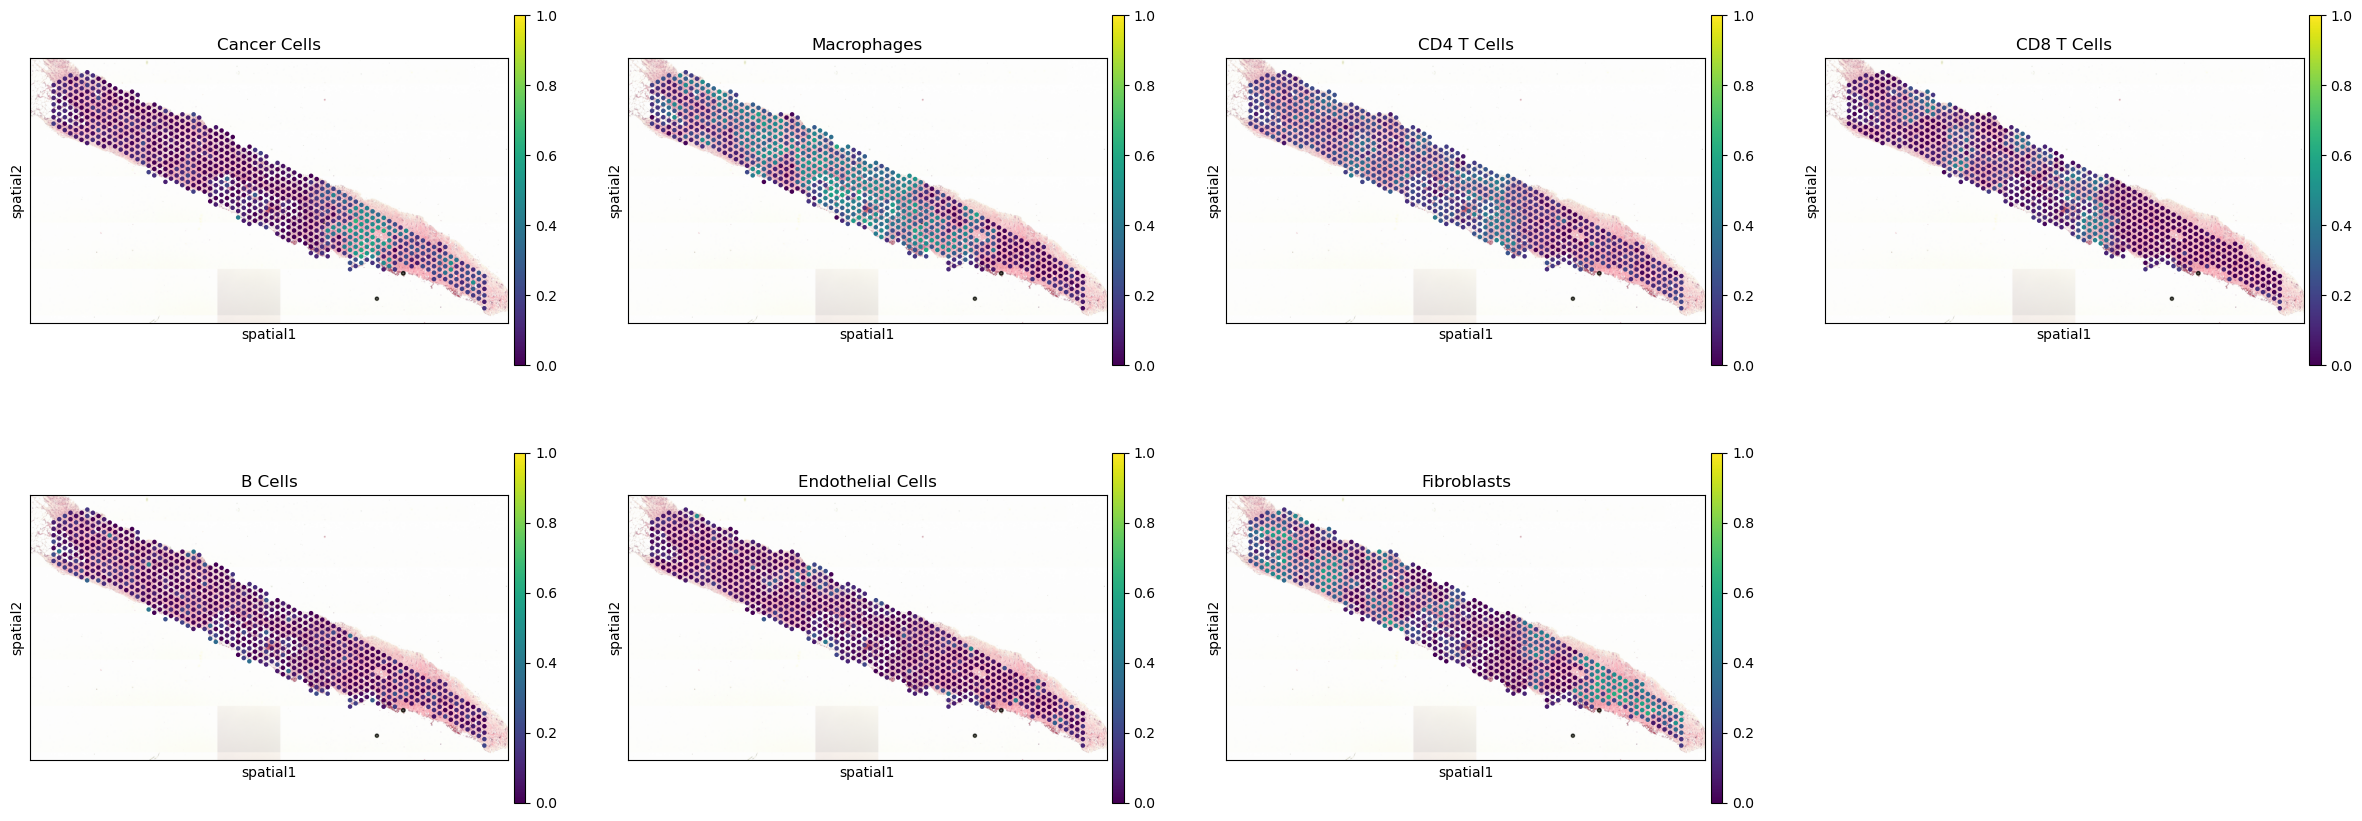

AnnData object with n_obs × n_vars = 763 × 2141
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'


Deconvoluting Remaining Spots: 100%|██████████| 763/763 [01:57<00:00,  6.52it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1',
       'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACAGGTTATTGCACC-1' 'AACCGCGGTAACTACA-1'
 'AACCTGACAGTGCCGC-1' 'AACGAAGCGTGGAAGT-1']
Added layer: CD8_T_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Macrophages_genes_pass1 (Shape: (763, 2141))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Fibroblasts_genes_pass1 (Shape: (763, 2141))
Added layer: B_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Cancer_Cells_genes_pass1 (Shape: (763, 2141))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1'

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 1771 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 3370 Filtered spots: 4991 to 3370
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 3370/3370 [12:11<00:00,  4.61it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATATTCTTGCGAA-1', 'AACATCGCGTGACCAC-1', 'AACATCTAATGACCGG-1', 'AACATGACGCAGCGTG-1']
AnnData spots 1-10: ['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATATTCTTGCGAA-1', 'AACATCGCGTGACCAC-1', 'AACATCTAATGACCGG-1', 'AACATGACGCAGCGTG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


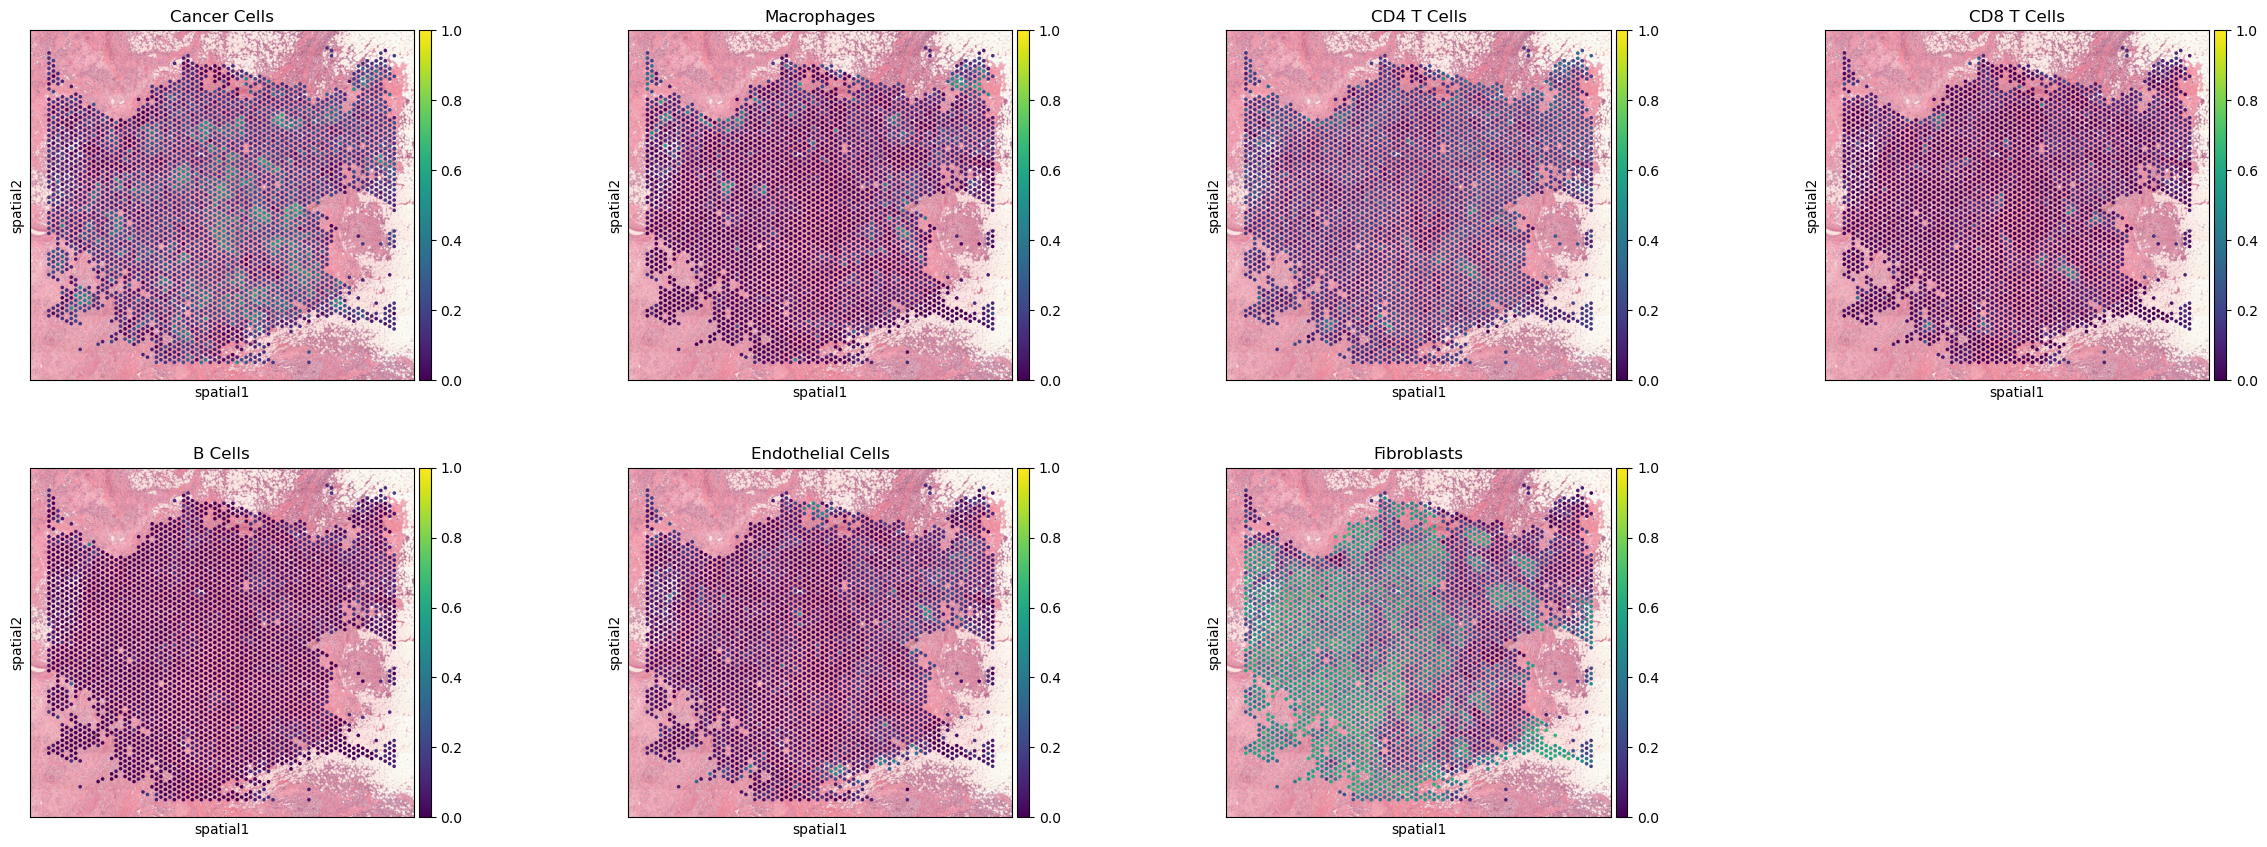

AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'


Deconvoluting Remaining Spots: 100%|██████████| 3370/3370 [15:28<00:00,  3.63it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1',
       'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1'],
      dtype='object')
Parquet spot names format: ['AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1' 'AACAGGATTCATAGTT-1'
 'AACAGGTTATTGCACC-1' 'AACAGGTTCACCGAAG-1']
Added layer: CD8_T_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Macrophages_genes_pass1 (Shape: (3370, 1771))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Fibroblasts_genes_pass1 (Shape: (3370, 1771))
Added layer: B_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Cancer_Cells_genes_pass1 (Shape: (3370, 1771))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACGTGCATCGCAC-1', 'AACACTTGGCAA

In [26]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in path_list:
    
    sample_name = path.split('/')[-2]
    
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='../output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=25)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()

    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    # Run cell proportion model
    model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    sc.pl.spatial(
        prop_adata,
        color=["Cancer Cells", "Macrophages", "CD4 T Cells", "CD8 T Cells", "B Cells", "Endothelial Cells", "Fibroblasts"], vmin=0, vmax=1)

    print(prop_adata)


    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                alpha=0.9, 
                lambda_reg_gex=0.1,
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

# Analysis after CITEgeist run (Loaded without having to re-run) 

In [27]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [28]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


In [29]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
import seaborn as sns

# Reload the model module if you're actively developing

path_to_biopsy ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS19-12947/outs"

path_to_surgical ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-10767_rep/outs"


path_list = [path_to_biopsy, path_to_surgical]

In [31]:
# Need to add in all that code on analysis of the data

import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing

prop_gex_adatas = {}

for path in path_list:
    sample_name = path.split('/')[-2]
    
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='../examples/output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=25)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()

    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")


    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)
    
    prop_gex_adatas[sample_name] = prop_gex_adata


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2141 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 763 Filtered spots: 794 to 763
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../examples/output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 1771 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 3370 Filtered spots: 4991 to 3370
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../examples/output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATATTCTTGCGA

In [32]:
print(prop_gex_adatas)

{'PVS19-12947': AnnData object with n_obs × n_vars = 763 × 2141
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'B_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'PVS23-10767_rep': AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_contr

In [ ]:
# Histogram code

